In [11]:
import ydf
import pandas as pd
from ydf import Task

In [12]:
data = pd.read_csv("./inputs/train.csv")

In [13]:
import numpy as np

def split_dataset(dataset, test_ratio=0.20):
    """
    Split into train and test sets (adjust as needed)
    :param dataset:
    :param test_ratio:
    :return: The train and test sets
    """
    test_indices = np.random.rand(len(dataset)) < test_ratio
    return dataset[~test_indices], dataset[test_indices]

In [14]:
train_data, test_data = split_dataset(data)
print("{} examples in training, {} examples in testing.".format(
    len(train_data), len(test_data)))

599743 examples in training, 150257 examples in testing.


In [15]:
# Define the label column
label = "Listening_Time_minutes"

In [16]:
# Initialize the learner (regression task shown here)
learner = ydf.RandomForestLearner(label=label, task=Task.REGRESSION)

In [17]:
# Train the model
model = learner.train(train_data)

Train model on 599743 examples
Model trained in 0:07:11.746626


In [18]:
# Evaluate on the test set
evaluation = model.evaluate(test_data)

# For regression, print RMSE
print("Root Mean Squared Error (RMSE):", evaluation.rmse)

Root Mean Squared Error (RMSE): 12.894047048143465


In [20]:
from sklearn.metrics import root_mean_squared_error

# Predict on the test set
predictions = model.predict(test_data)

# Extract true labels
true_values = test_data["Listening_Time_minutes"]  # Replace "price" with your label column name

# Compute RMSE
rmse = root_mean_squared_error(true_values, predictions)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 12.894047045352751


In [21]:
model.variable_importances()["NUM_AS_ROOT"]

[(148.0, 'Episode_Length_minutes'),
 (83.0, 'Number_of_Ads'),
 (38.0, 'Host_Popularity_percentage'),
 (18.0, 'Episode_Title'),
 (7.0, 'Podcast_Name'),
 (5.0, 'Episode_Sentiment'),
 (1.0, 'Guest_Popularity_percentage')]

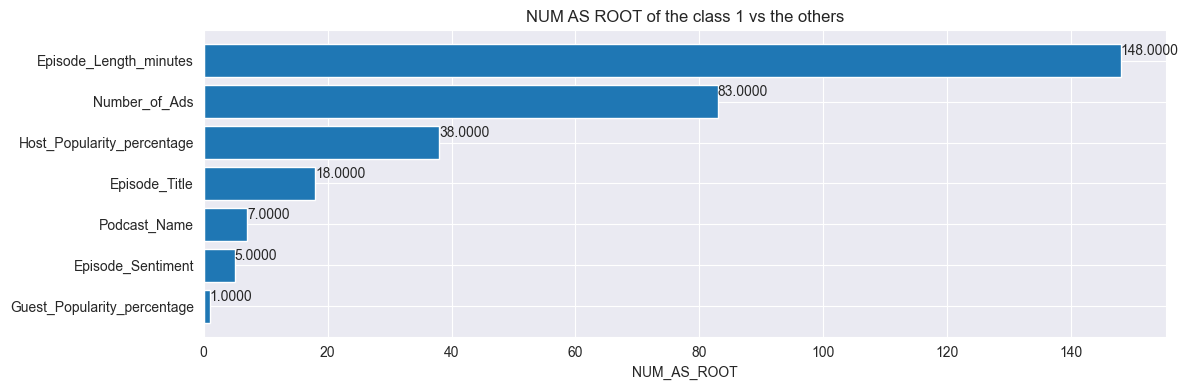

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Mean decrease in AUC of the class 1 vs the others.
variable_importance_metric = "NUM_AS_ROOT"
variable_importances = model.variable_importances()[variable_importance_metric]

# Extract the feature name and importance values.
#
# `variable_importances` is a list of <feature, importance> tuples.
feature_names = [vi[1] for vi in variable_importances]
feature_importances = [vi[0] for vi in variable_importances]

# The features are ordered in decreasing importance value.
feature_ranks = range(len(feature_names))

bar = plt.barh(feature_ranks, feature_importances, label=[str(x) for x in feature_ranks])
plt.yticks(feature_ranks, feature_names)
plt.gca().invert_yaxis()

# TODO: Replace with "plt.bar_label()" when available.
# Label each bar with values
for importance, patch in zip(feature_importances, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{importance:.4f}", va="top")

plt.xlabel(variable_importance_metric)
plt.title("NUM AS ROOT of the class 1 vs the others")
plt.tight_layout()
plt.show()